In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from sklearn.model_selection import train_test_split
# cross validation
from sklearn.model_selection import cross_val_score

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [80]:
df = pd.read_csv('concrete_data.csv')

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [82]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [83]:
X = df.drop('Strength', axis=1)
y = df['Strength']


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 95.97094009110684
R^2 Score: 0.6275531792314848


In [ ]:
np.mean(cross_val_score(lr, X, y, scoring='neg_mean_squared_error'))

np.float64(-128.137756129647)

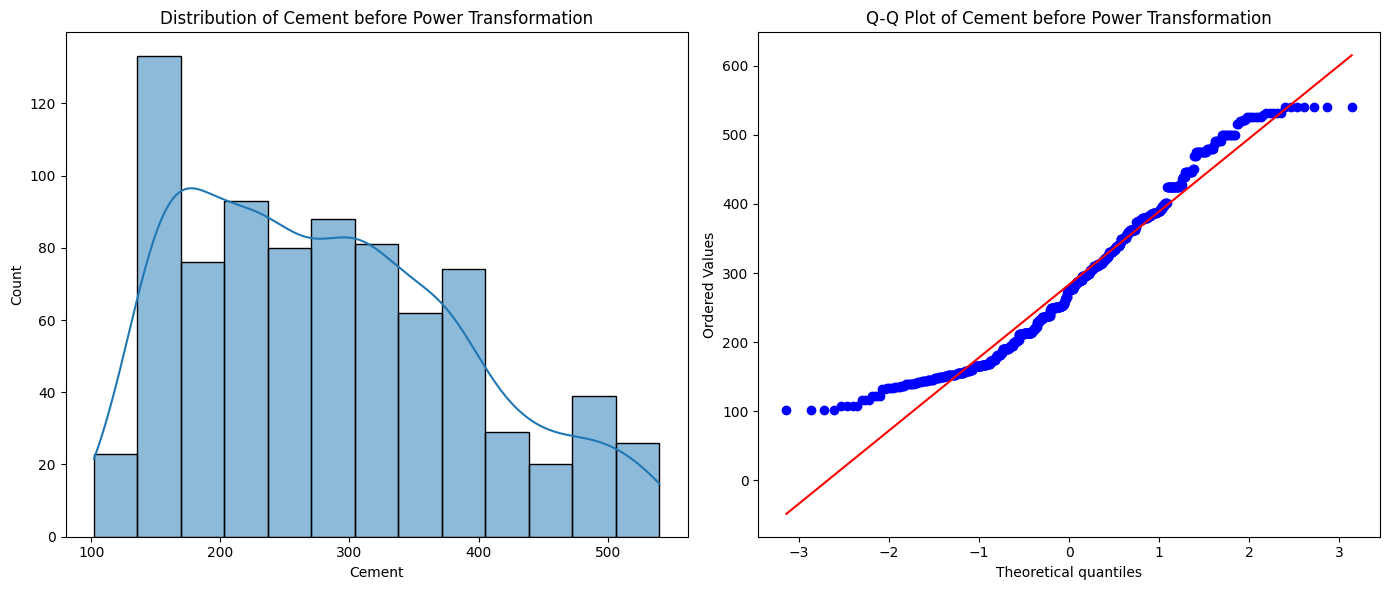

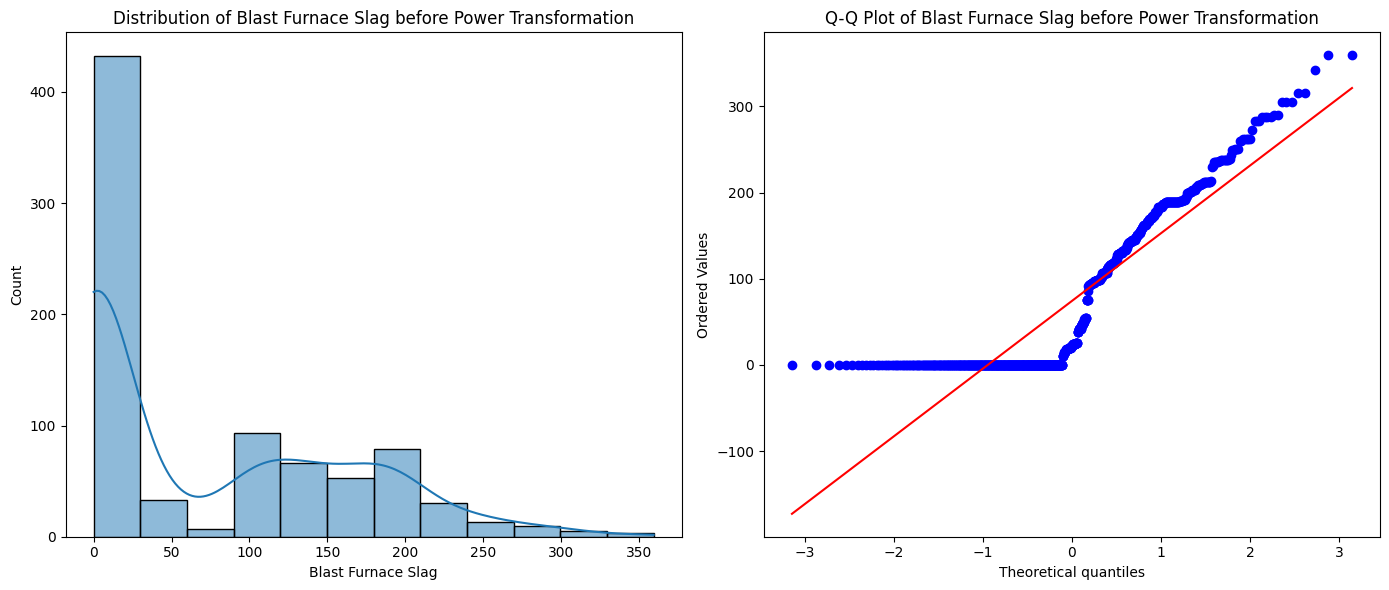

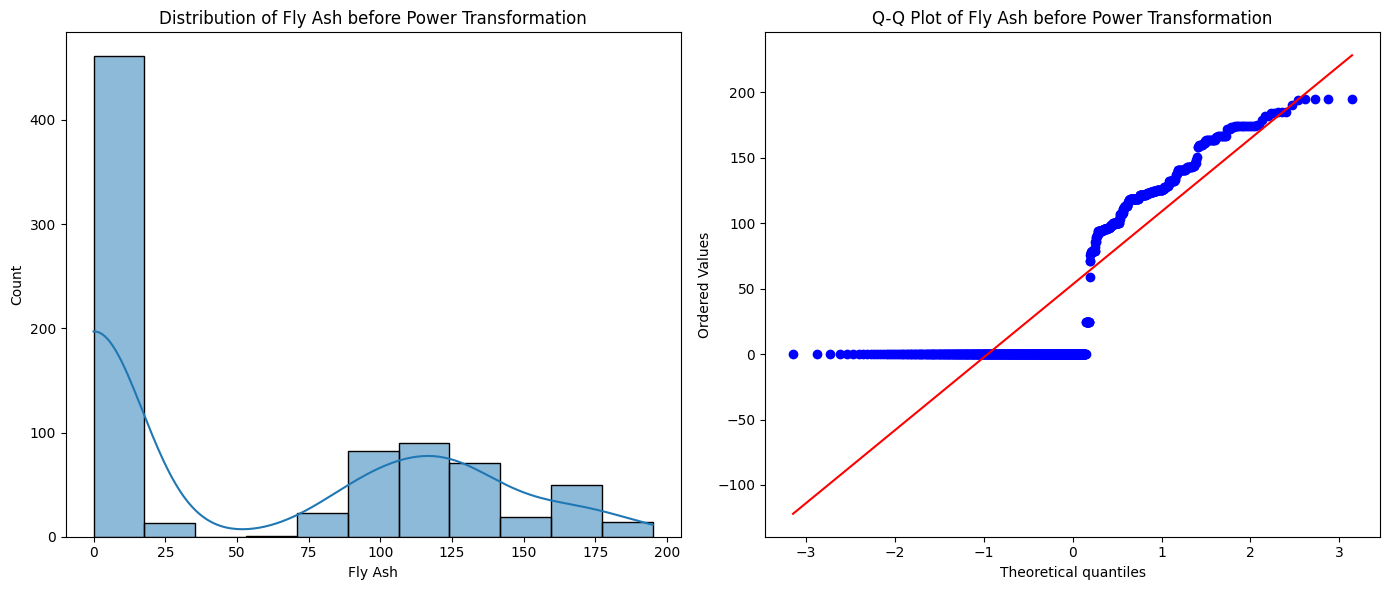

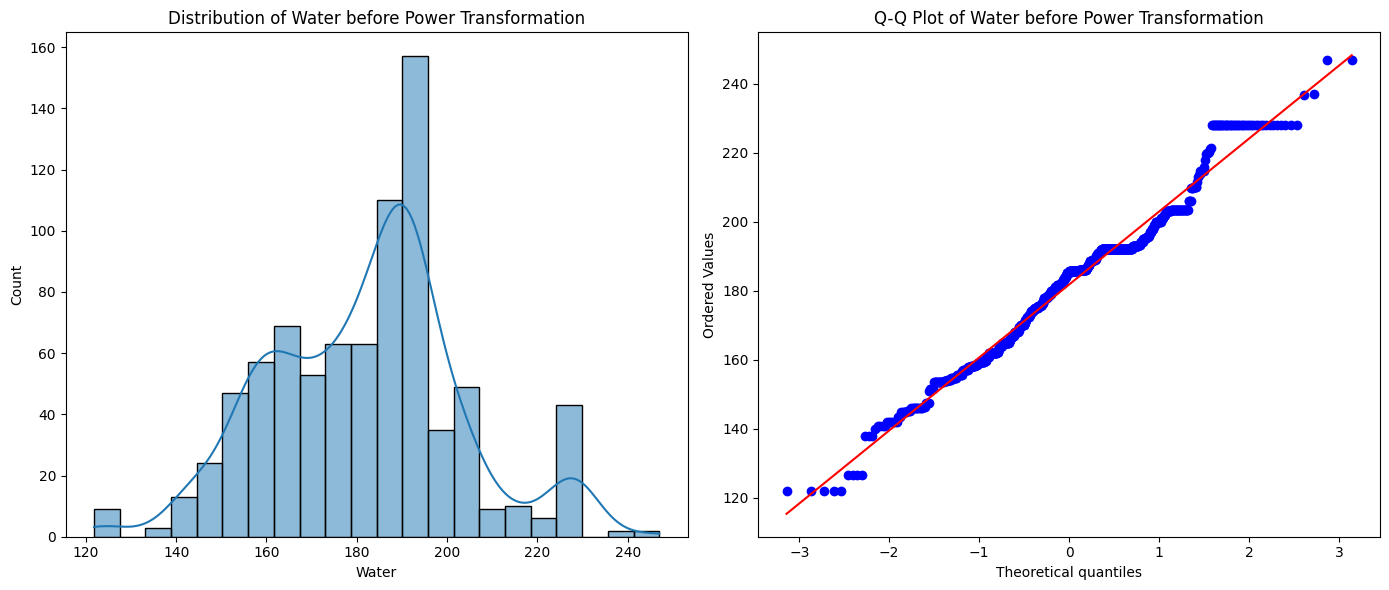

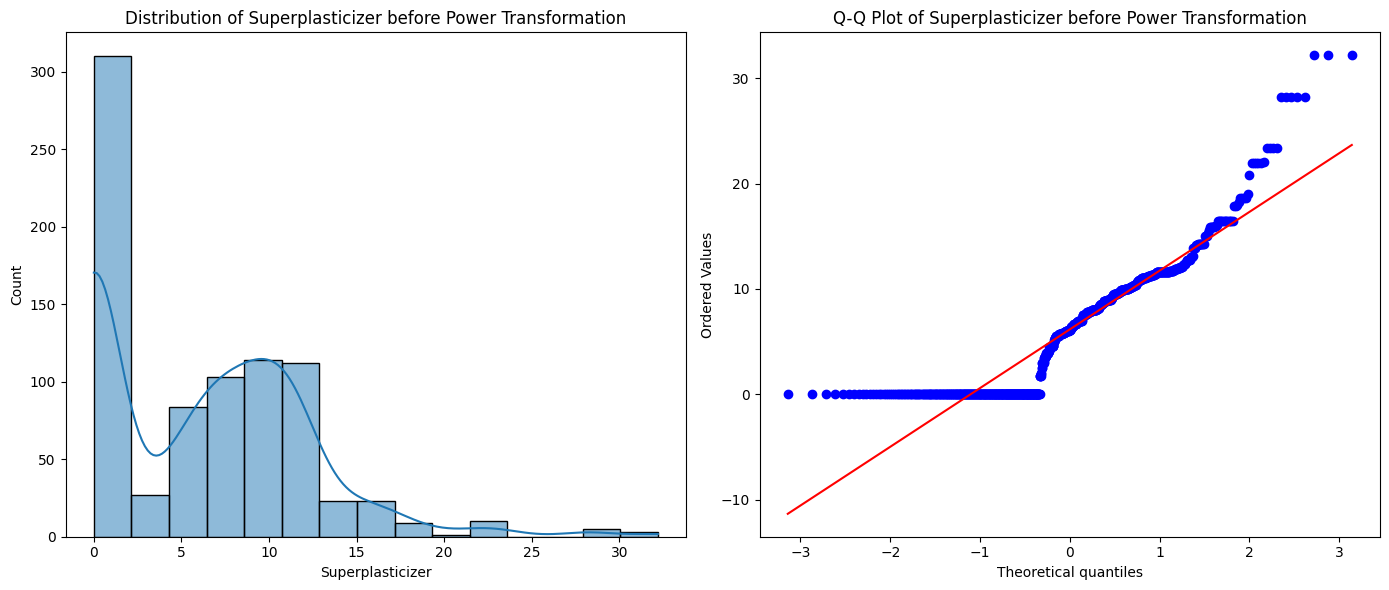

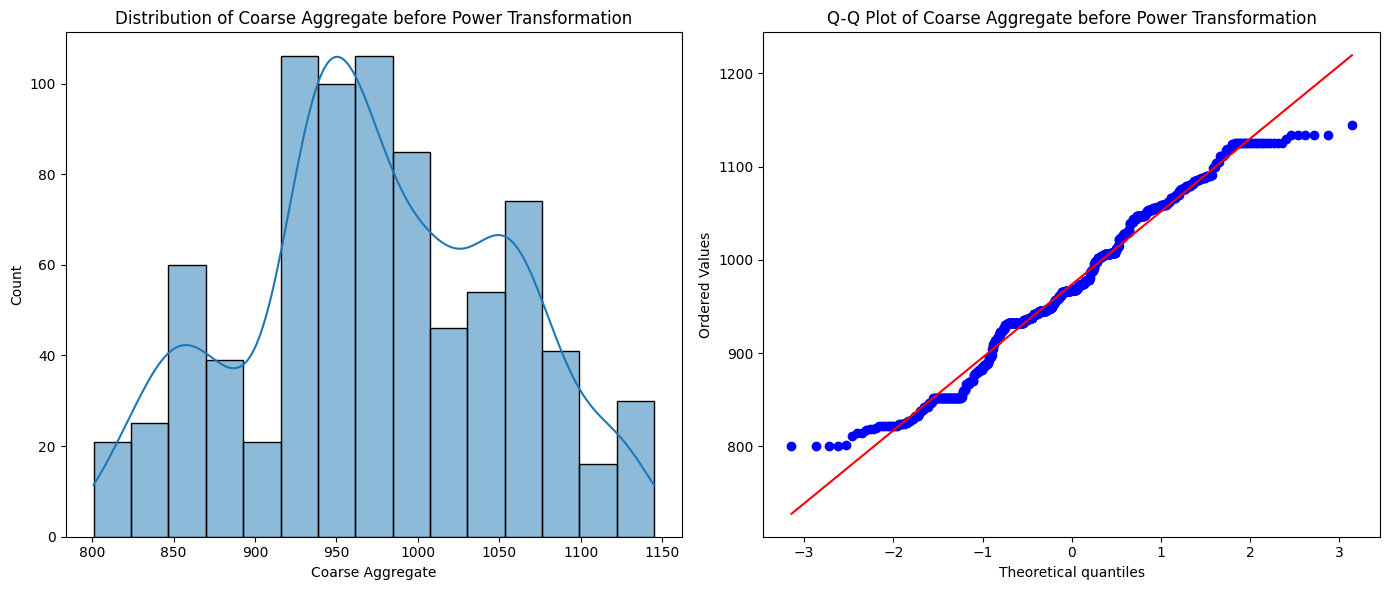

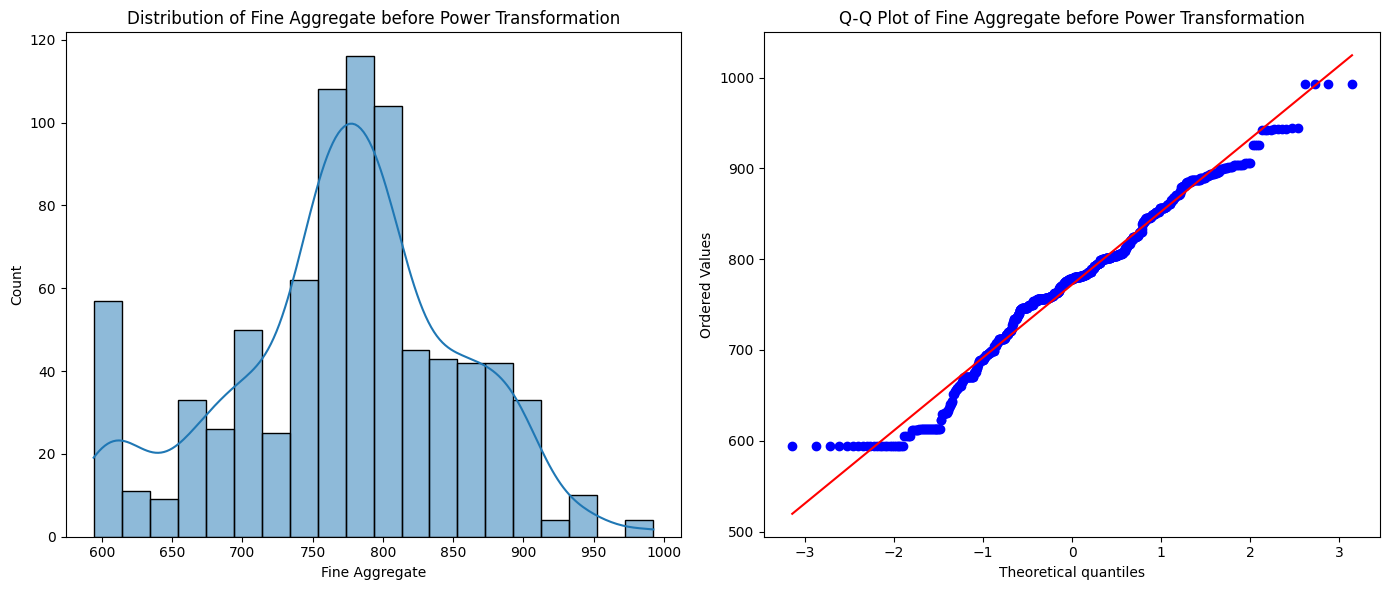

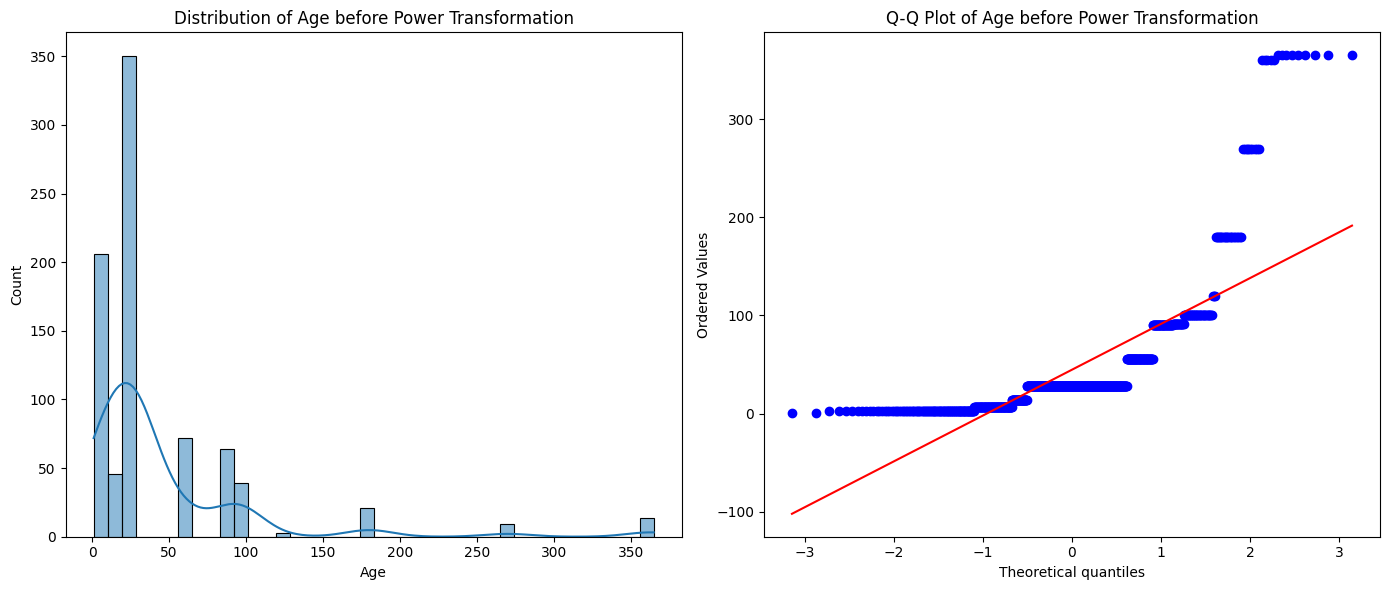

In [87]:
for col in X_train.columns:
    plt.figure(figsize=(14, 6))
    
    # Distribution plot
    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col} before Power Transformation")
    
    # Q-Q plot
    plt.subplot(1, 2, 2)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col} before Power Transformation")
    
    plt.tight_layout()
    plt.show()

In [88]:
power = PowerTransformer(method='yeo-johnson')

X_train_transformed = power.fit_transform(X_train)
X_test_transformed = power.transform(X_test)

# check the lamda values for each feature / column
print("Lambda values for each feature:")

dataframe = pd.DataFrame({
    'cols': X_train.columns,
    'lamda': power.lambdas_
})


Lambda values for each feature:


In [89]:
dataframe

,cols,lamda
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [90]:
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 47.36342223268907
R^2 Score: 0.8161906508935355


In [91]:
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=X_train.columns)

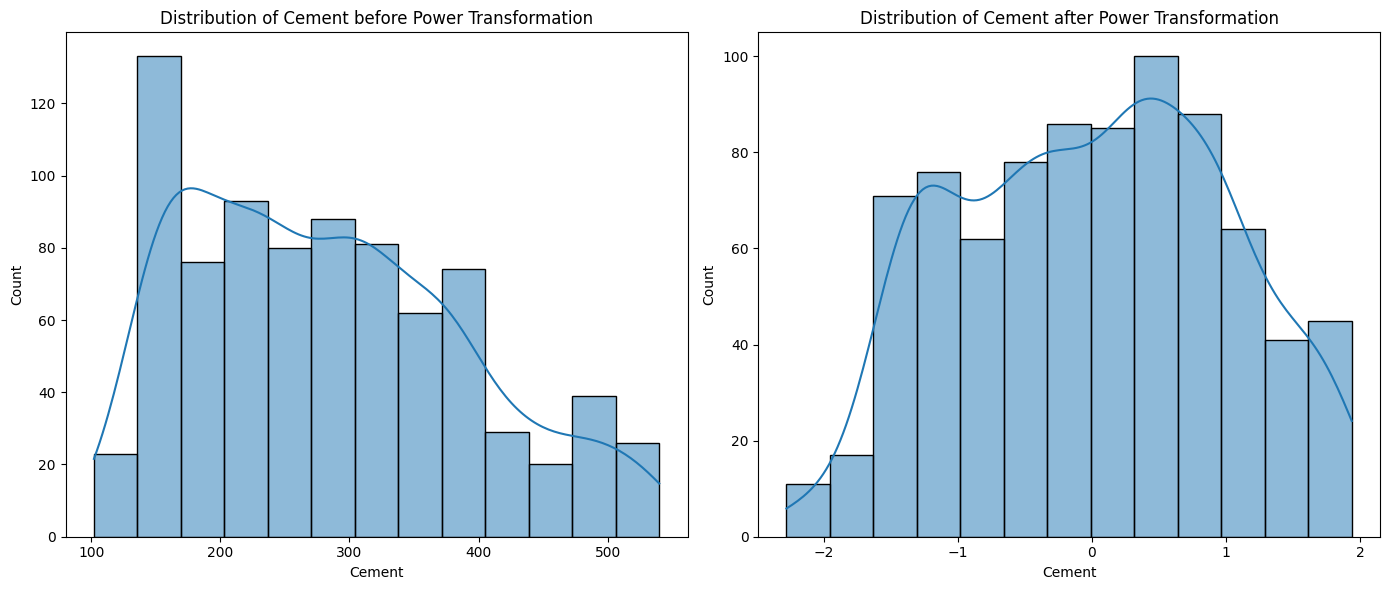

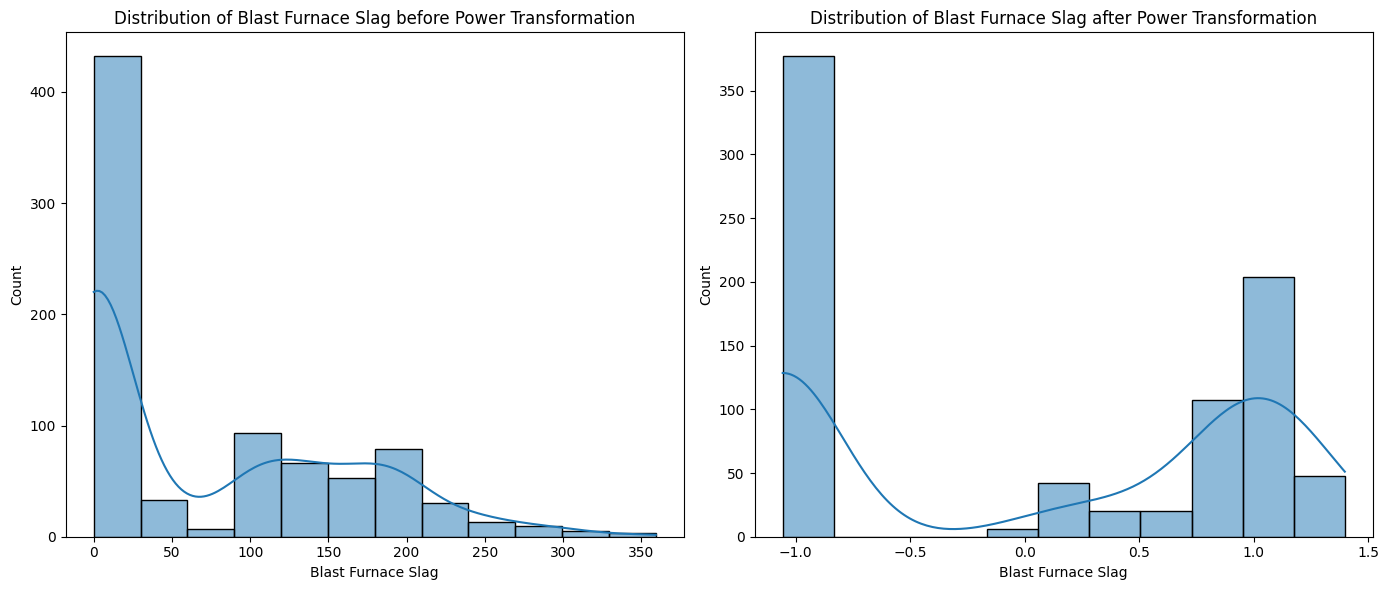

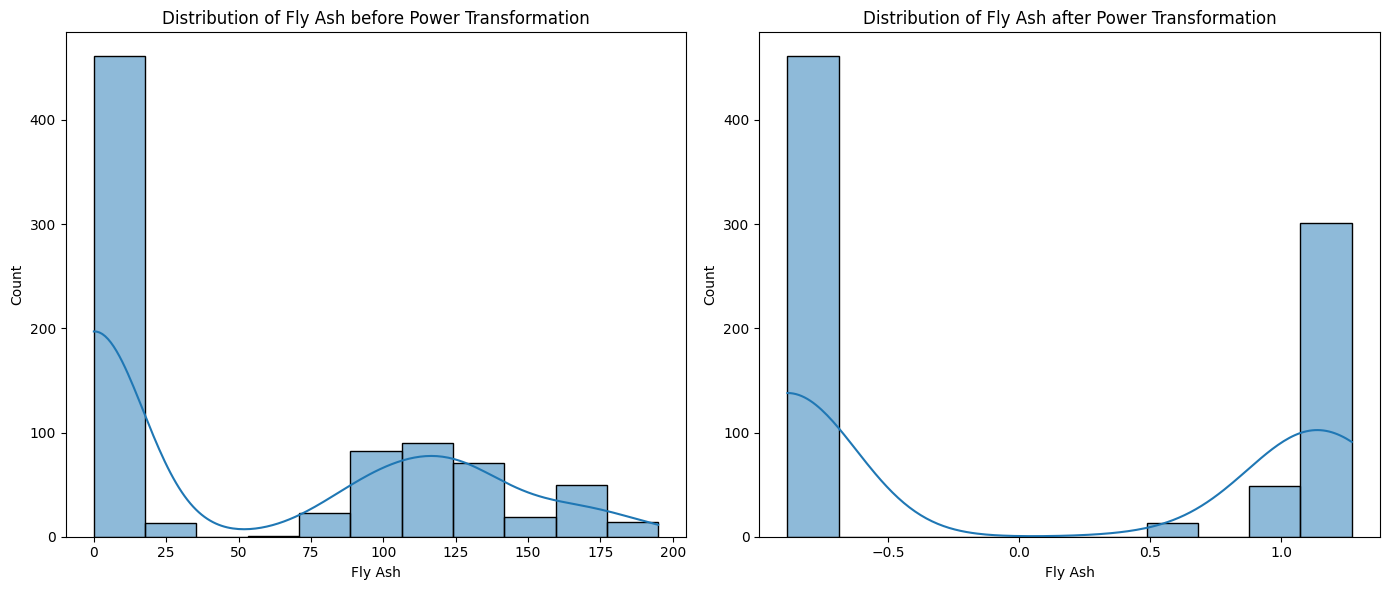

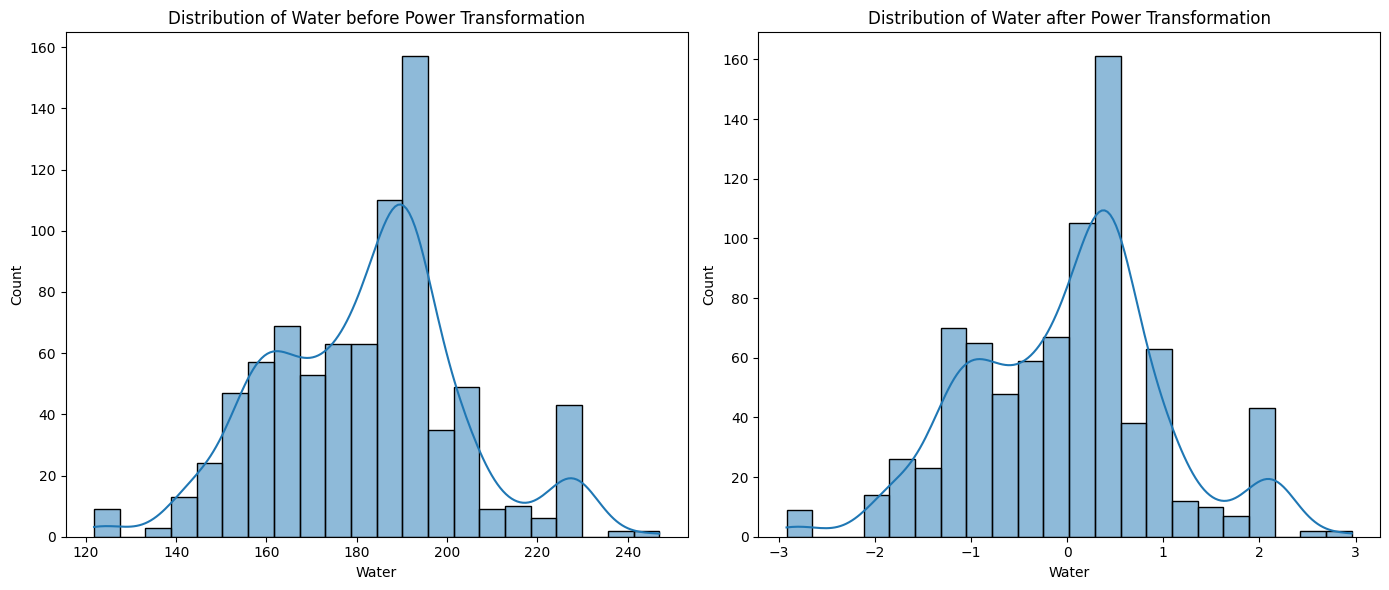

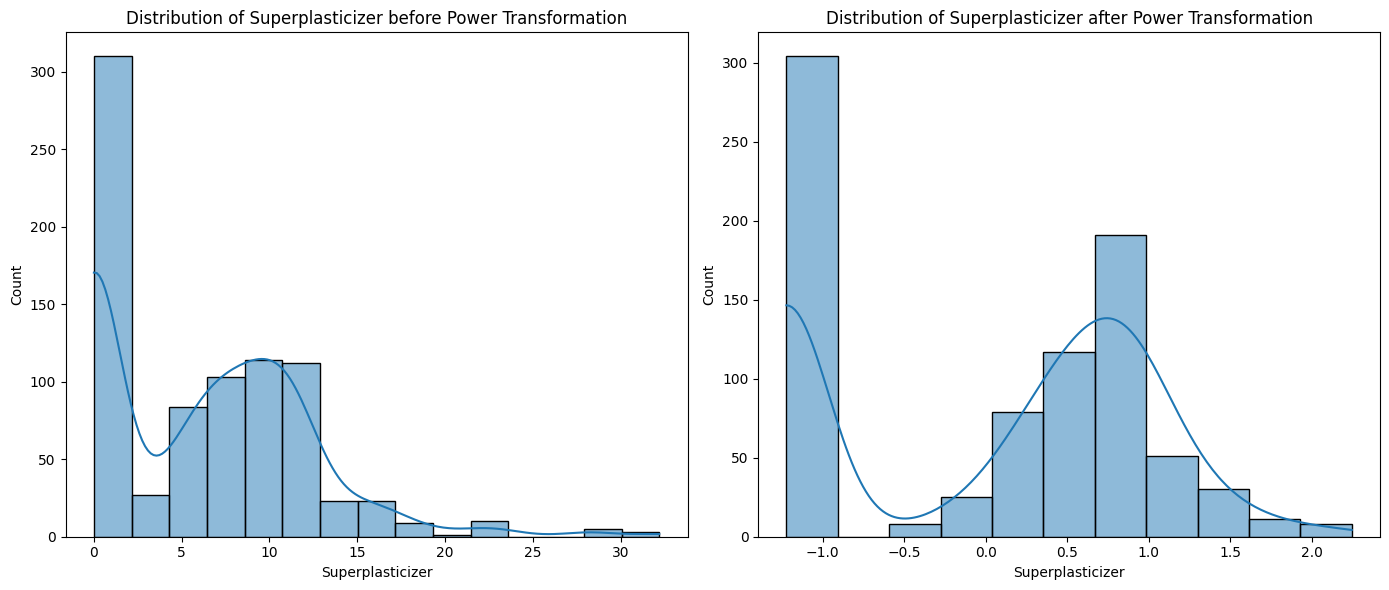

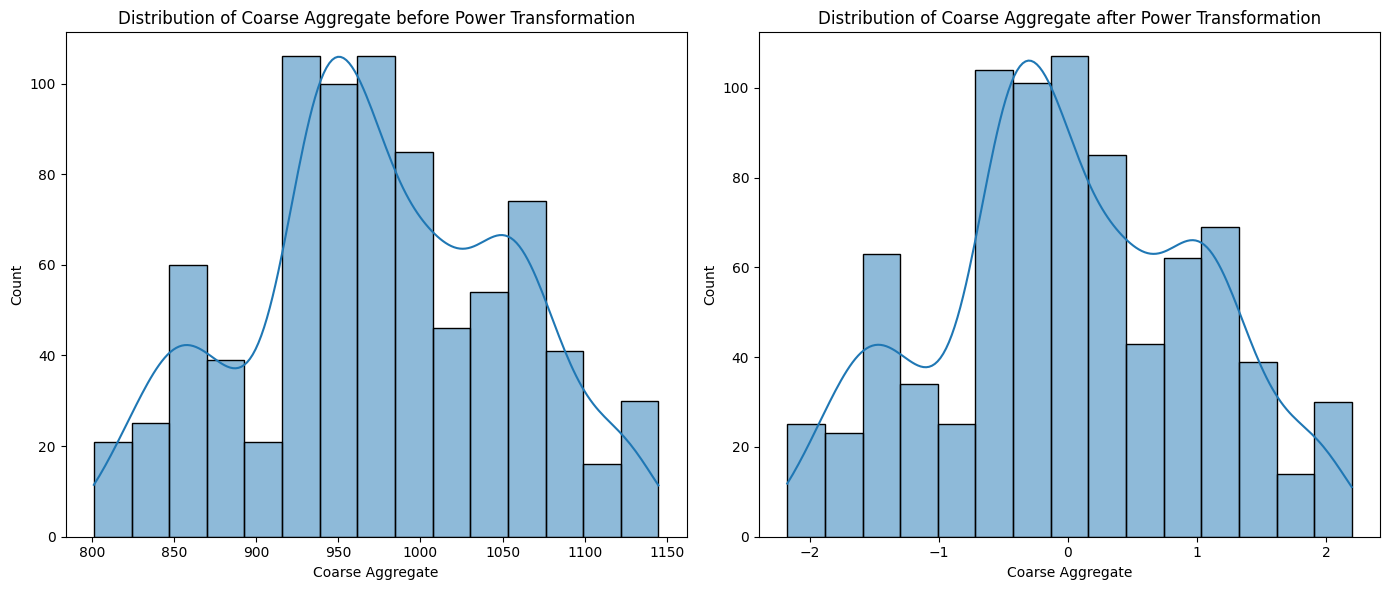

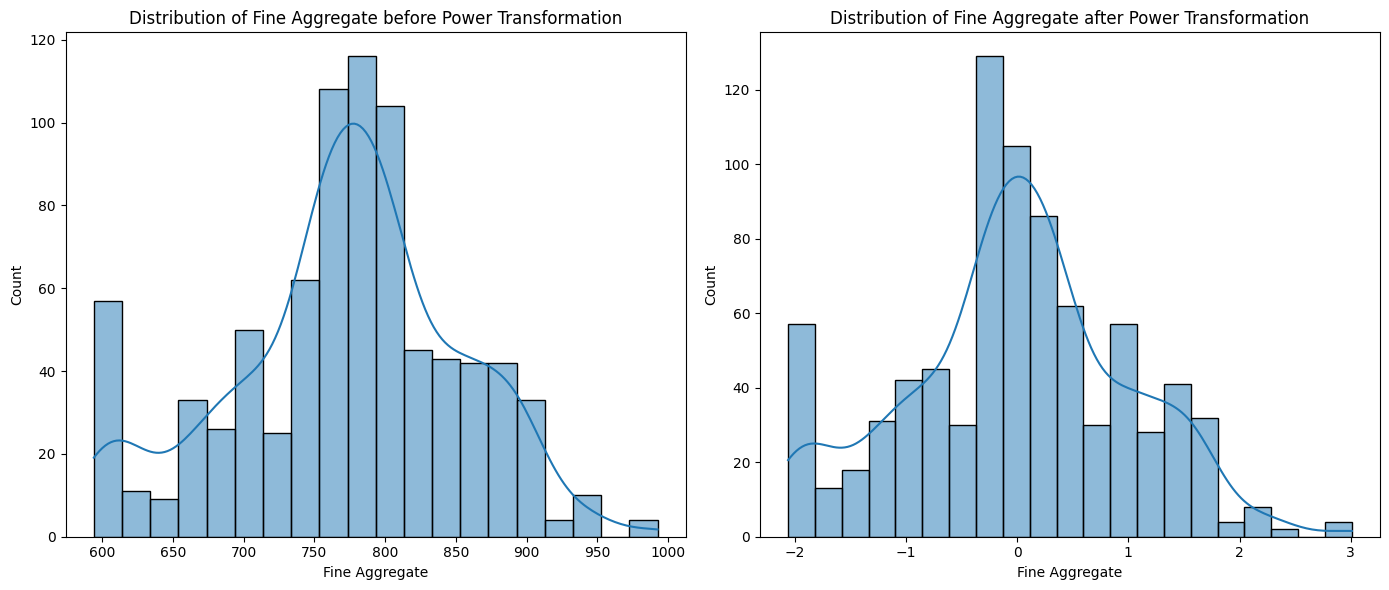

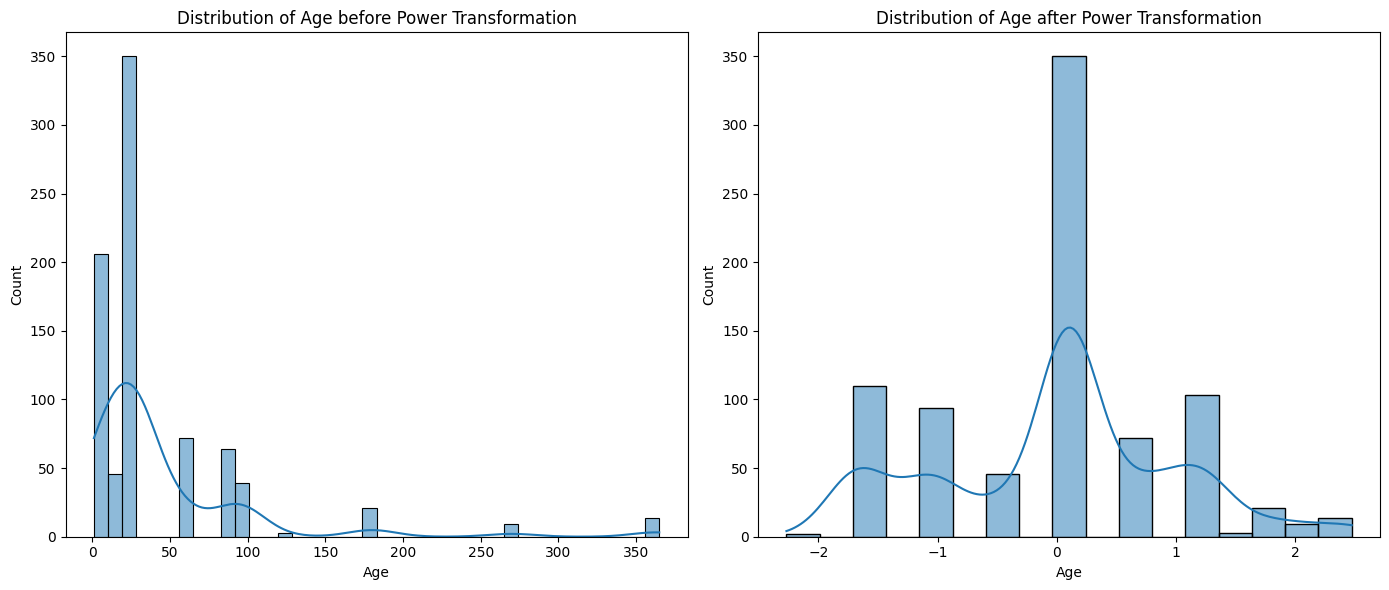

In [92]:
for col in X_train_transformed_df.columns:
    plt.figure(figsize=(14, 6))

    # Before Transformation Distribution plot

    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col} before Power Transformation")
    
    
    # After Transformation Distribution plot
    plt.subplot(1, 2, 2)
    sns.histplot(X_train_transformed_df[col], kde=True)
    plt.title(f"Distribution of {col} after Power Transformation")
    
    
    plt.tight_layout()
    plt.show()